In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ad_df = pd.read_csv("ad_spend_data.csv")
web_df = pd.read_csv("web_analytics_log.csv")
crm_df = pd.read_csv("crm_conversion_data.csv")

In [2]:
total_spend = ad_df["amount_spent_usd"].sum()

print(f"Total Spend: ${total_spend:,.2f}")

Total Spend: $1,236,166.50


In [3]:
total_revenue = crm_df["revenue_usd"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $157,479.27


In [4]:
total_clicks = ad_df["clicks"].sum()

print(total_clicks)

948432


In [5]:
total_impressions = ad_df["impressions"].sum()

print(total_impressions)

28405568


In [6]:
ctr = (
    total_clicks /
    total_impressions
) * 100

print(f"CTR: {ctr:.2f}%")

CTR: 3.34%


In [7]:
cpc = (
    total_spend /
    total_clicks
)

print(f"CPC: ${cpc:.2f}")

CPC: $1.30


In [8]:
total_conversions = len(crm_df)

print(total_conversions)

600


In [9]:
cac = (
    total_spend /
    total_conversions
)

print(f"CAC: ${cac:.2f}")

CAC: $2060.28


In [10]:
roas = (
    total_revenue /
    total_spend
)

print(f"ROAS: {roas:.2f}")

ROAS: 0.13



Channel Performance Analysis


In [11]:
channel_spend = (
    ad_df
    .groupby("channel")["amount_spent_usd"]
    .sum()
    .sort_values(ascending=False)
)

channel_spend

channel
Google_Search    483302.68
Meta_Facebook    304221.15
LinkedIn         252163.24
TikTok           150570.08
Email             45909.35
Organic               0.00
Name: amount_spent_usd, dtype: float64

In [12]:
channel_revenue = (
    crm_df
    .groupby("last_touch_channel")["revenue_usd"]
    .sum()
    .sort_values(ascending=False)
)

channel_revenue

last_touch_channel
Google_Search    43583.44
Meta_Facebook    41564.63
TikTok           24587.92
LinkedIn         16716.83
Organic          16696.59
Email            14329.86
Name: revenue_usd, dtype: float64

<Axes: title={'center': 'Spend By Channel'}, xlabel='channel'>

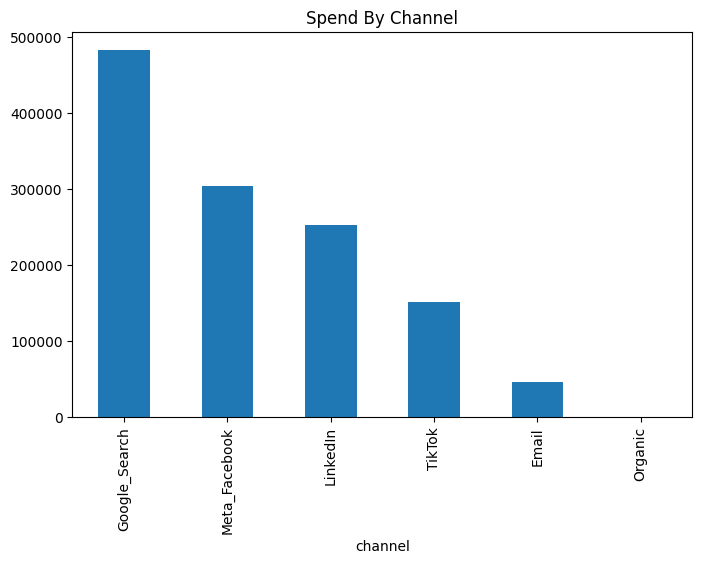

In [13]:
channel_spend.plot(
    kind="bar",
    figsize=(8,5),
    title="Spend By Channel"
)

<Axes: title={'center': 'Revenue By Channel'}, xlabel='last_touch_channel'>

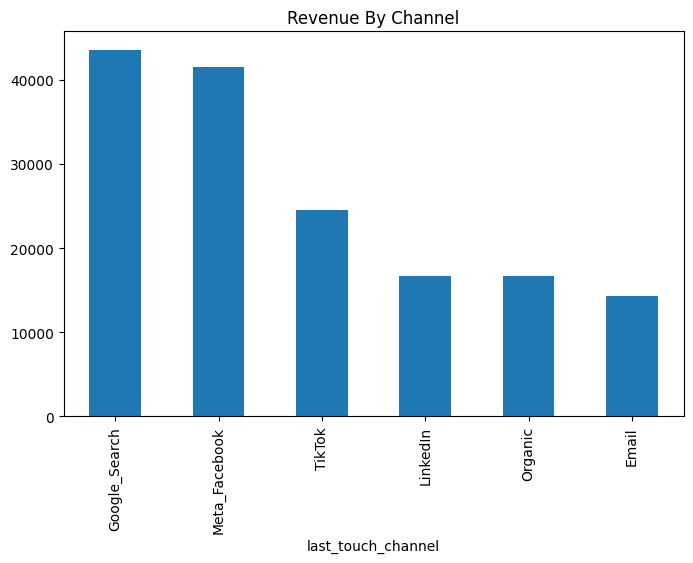

In [14]:
channel_revenue.plot(
    kind="bar",
    figsize=(8,5),
    title="Revenue By Channel"
)

In [15]:
campaign_spend = (
    ad_df
    .groupby("campaign")["amount_spent_usd"]
    .sum()
    .sort_values(ascending=False)
)

campaign_spend.head(10)

campaign
GSearch_Generic       167827.60
GSearch_Brand         158421.98
GSearch_Competitor    157053.10
LinkedIn_Lead         130127.99
LinkedIn_B2B          122035.25
FB_Retargeting        104496.64
FB_Awareness          100486.74
FB_Lookalike           99237.77
TikTok_Promo           77511.58
TikTok_Video1          73058.50
Name: amount_spent_usd, dtype: float64

In [16]:
sessions = web_df["session_id"].nunique()

users = web_df["user_id"].nunique()

conversions = len(crm_df)

print("Sessions:", sessions)
print("Users:", users)
print("Conversions:", conversions)

Sessions: 6016
Users: 2000
Conversions: 600
